# HydrAI — Tree Models comparison on test set

Compare **Random Forest**, **Gradient Boosting**, **XGBoost**, and **AdaBoost** predictions against held-out test data.

**Prerequisites:** Run Main_4 with `IF_TREE_MODEL_EXPORT = True` so that `models/tree_models_*.joblib` exists.

**Steps:** Paths and flags → Load artifacts → Metrics table and ranking → Actual vs predicted (reactor exit) → MAPE per target.

In [1]:
import os
import sys
import glob
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

current_dir = Path(os.getcwd())
project_root = current_dir if (current_dir / 'src').exists() else current_dir.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Paths and flags

In [2]:
# ── Section 1: Paths and flags ────────────────────────────────────────────────
IF_PLOT_SHOWN  = True
IF_PLOT_EXPORT = False

MODELS_DIR = project_root / "models"
ARTIFACT_PATTERN = "tree_models_*.joblib"

DISPLAY_NAMES = {
    'random_forest':      'Random Forest',
    'gradient_boosting':  'Gradient Boosting',
    'xgboost':            'XGBoost',
    'adaboost':           'AdaBoost',
}

print(f"Plot: {IF_PLOT_SHOWN}  |  Export: {IF_PLOT_EXPORT}")

Plot: True  |  Export: False


## 2. Load artifacts

Load the latest `tree_models_*.joblib` per mode exported by Main_4.  Each artifact contains the trained models, scaler, train/test splits, and column names.

In [3]:
# ── Section 2: Load artifacts ─────────────────────────────────────────────────
artifact_files = sorted(glob.glob(str(MODELS_DIR / ARTIFACT_PATTERN)), reverse=True)
if not artifact_files:
    raise FileNotFoundError(
        f"No model artifacts in {MODELS_DIR}. Run Main_4 with IF_TREE_MODEL_EXPORT=True first."
    )

artifacts_by_mode = {}
seen_modes = set()
for fpath in artifact_files:
    fname = Path(fpath).stem
    mode = fname.replace('tree_models_', '').rsplit('_', 2)[0]
    if mode in seen_modes:
        continue
    seen_modes.add(mode)
    artifacts_by_mode[mode] = joblib.load(fpath)
    model_keys = list(artifacts_by_mode[mode]['models'].keys())
    n_test = len(artifacts_by_mode[mode]['y_test'])
    print(f"  [{mode}] Loaded {Path(fpath).name}  |  models: {model_keys}  |  test samples: {n_test}")

print(f"\nModes available: {list(artifacts_by_mode.keys())}")

OMP: pid 7087 tid 11523 thread 3 bound to OS proc set {undefined}
OMP: pid 7087 tid 259 thread 0 bound to OS proc set {undefined}
OMP: pid 7087 tid 11779 thread 4 bound to OS proc set {undefined}
OMP: pid 7087 tid 14595 thread 2 bound to OS proc set {undefined}
OMP: pid 7087 tid 12547 thread 7 bound to OS proc set {undefined}
OMP: pid 7087 tid 14851 thread 1 bound to OS proc set {undefined}
OMP: pid 7087 tid 12291 thread 6 bound to OS proc set {undefined}
OMP: pid 7087 tid 12035 thread 5 bound to OS proc set {undefined}
  [exit] Loaded tree_models_exit_20260228_203325.joblib  |  models: ['random_forest', 'gradient_boosting', 'xgboost', 'adaboost']  |  test samples: 152

Modes available: ['exit']


## 3. Model comparison — metrics

For each model and target compute **R²**, **MAE**, **MedAE**, **RMSE**, **NRMSE**, **MAPE**, **MaxErr**, and **MBE** on the test set.  Display a summary table (mean across targets) and a model ranking sorted by MAPE.

In [4]:
# ── Section 3: Model comparison — metrics ─────────────────────────────────────
rows = []
for mode, art in artifacts_by_mode.items():
    models       = art['models']
    X_test_s     = art['X_test_s']
    y_test       = art['y_test']
    target_names = art['target_cols']

    for model_key, model in models.items():
        y_pred = model.predict(X_test_s)
        y_pred_df = pd.DataFrame(y_pred, columns=target_names, index=y_test.index)

        for tgt in target_names:
            y_true_col = y_test[tgt].values
            y_pred_col = y_pred_df[tgt].values
            mask = np.abs(y_true_col) > 1e-12
            if mask.any():
                mape = np.mean(np.abs((y_true_col[mask] - y_pred_col[mask]) / y_true_col[mask])) * 100.0
            else:
                mape = np.nan

            residuals = y_pred_col - y_true_col
            abs_errors = np.abs(residuals)
            rmse = np.sqrt(mean_squared_error(y_true_col, y_pred_col))
            y_range = y_true_col.max() - y_true_col.min()
            nrmse = (rmse / y_range * 100.0) if y_range > 1e-12 else np.nan

            rows.append({
                'mode':    mode,
                'model':   DISPLAY_NAMES.get(model_key, model_key),
                'target':  tgt,
                'R2':      r2_score(y_true_col, y_pred_col),
                'MAE':     mean_absolute_error(y_true_col, y_pred_col),
                'MedAE':   np.median(abs_errors),
                'RMSE':    rmse,
                'NRMSE_%': nrmse,
                'MAPE_%':  mape,
                'MaxErr':  np.max(abs_errors),
                'MBE':     np.mean(residuals),
            })

df_metrics = pd.DataFrame(rows)

metric_cols = ['R2', 'MAE', 'MedAE', 'RMSE', 'NRMSE_%', 'MAPE_%', 'MaxErr', 'MBE']

# ── Summary table (mean over targets) ────────────────────────────────────────
summary = (
    df_metrics
    .groupby(['mode', 'model'])[metric_cols]
    .mean()
    .sort_values(['mode', 'R2'], ascending=[True, False])
)
print('=' * 80)
print('  Model comparison — mean metrics across all targets')
print('=' * 80)
print(summary.to_string())

# ── Model ranking ────────────────────────────────────────────────────────────
rank_cols = ['MAPE_%', 'NRMSE_%', 'MAE', 'MedAE', 'RMSE', 'MaxErr']
print()
print('=' * 80)
print('  Model ranking (by mean error — lower is better)')
print('=' * 80)
ranking = (
    df_metrics
    .groupby(['mode', 'model'])[rank_cols]
    .mean()
    .reset_index()
    .sort_values('MAPE_%')
    .reset_index(drop=True)
)
ranking.index = ranking.index + 1
ranking.index.name = 'rank'
print(ranking.to_string())

OMP: pid 7087 tid 14083 thread 0 bound to OS proc set {undefined}
OMP: pid 7087 tid 13571 thread 3 bound to OS proc set {undefined}
OMP: pid 7087 tid 11019 thread 1 bound to OS proc set {undefined}
OMP: pid 7087 tid 12803 thread 4 bound to OS proc set {undefined}
OMP: pid 7087 tid 13827 thread 2 bound to OS proc set {undefined}
OMP: pid 7087 tid 13315 thread 5 bound to OS proc set {undefined}
OMP: pid 7087 tid 13059 thread 6 bound to OS proc set {undefined}
OMP: pid 7087 tid 16387 thread 7 bound to OS proc set {undefined}
  Model comparison — mean metrics across all targets
                              R2           MAE         MedAE          RMSE   NRMSE_%     MAPE_%         MaxErr          MBE
mode model                                                                                                                 
exit Gradient Boosting  0.913818  11537.446751   8540.740346  16068.734112  4.962224   5.826797   71186.787495 -1529.796421
     XGBoost            0.873555  19789.691285 

## 4. Actual vs predicted — reactor exit outputs


For each exit-condition output, compare the **mean test value** (actual) against the **mean prediction** from every trained tree model.  Each target gets its own subplot so units and scales remain readable.

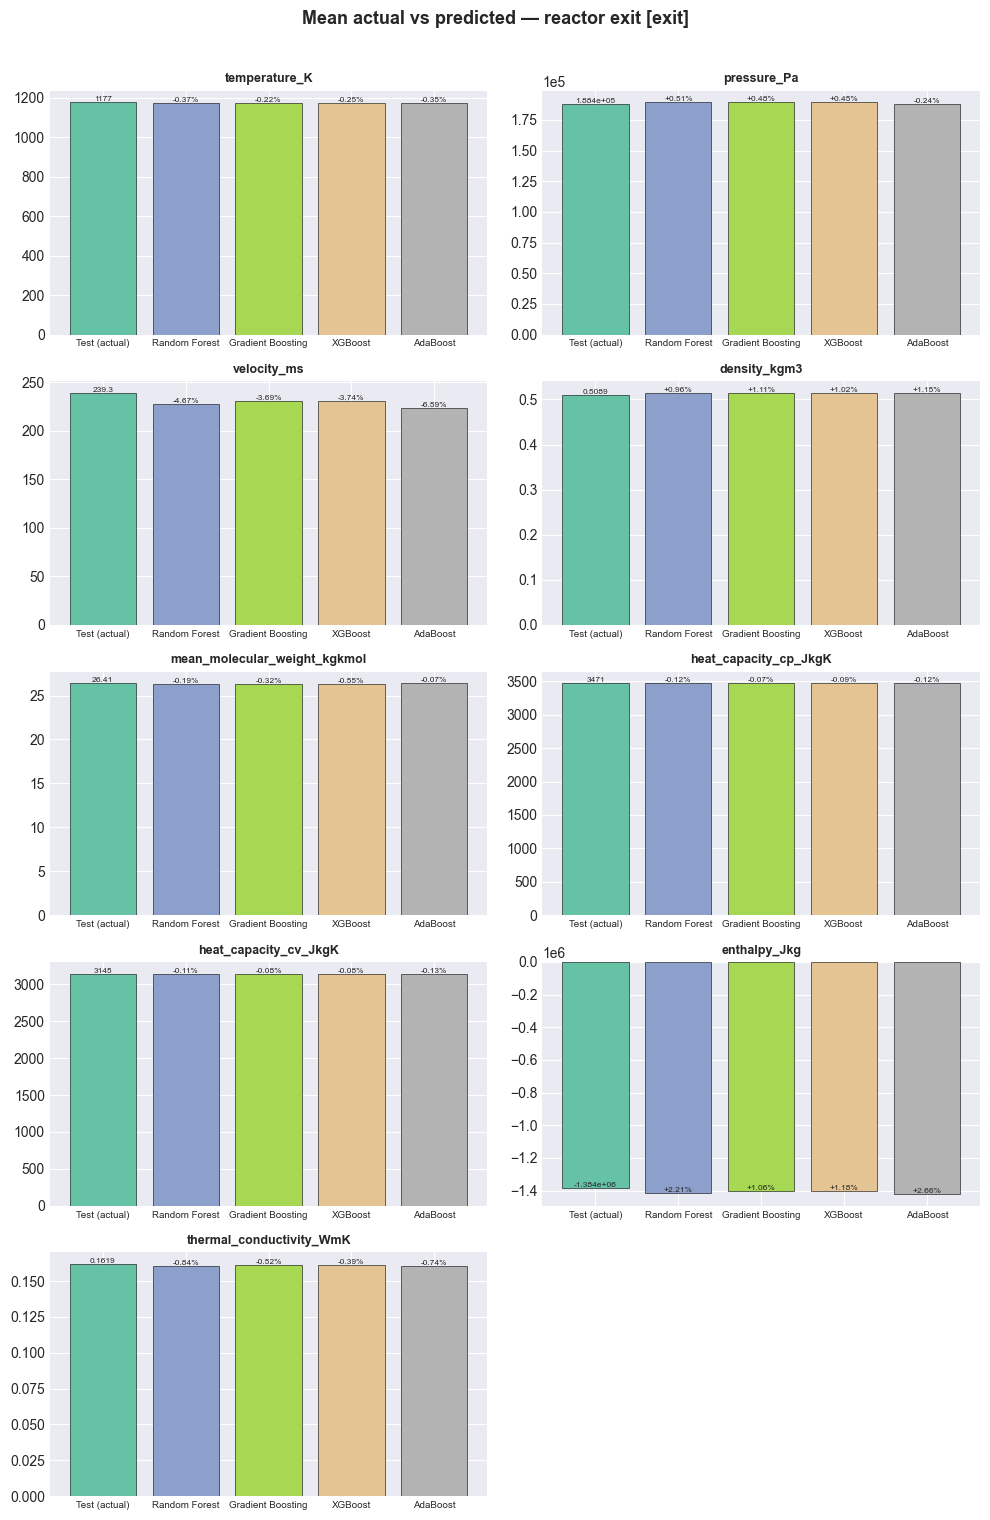

Actual vs Predicted comparison complete.


In [5]:
# ── Section 4: Actual vs Predicted bar charts (exit outputs) ────────────────
exit_mode = 'exit' if 'exit' in artifacts_by_mode else next(iter(artifacts_by_mode))
art      = artifacts_by_mode[exit_mode]
models   = art['models']
y_test   = art['y_test']
X_test_s = art['X_test_s']
target_names = art['target_cols']

predictions = {}
for model_key, model in models.items():
    y_pred = model.predict(X_test_s)
    predictions[DISPLAY_NAMES.get(model_key, model_key)] = pd.DataFrame(
        y_pred, columns=target_names, index=y_test.index
    )

model_labels = list(predictions.keys())
bar_labels   = ['Test (actual)'] + model_labels
colors       = plt.cm.Set2(np.linspace(0, 1, len(bar_labels)))

n_targets = len(target_names)
n_cols    = 2
n_rows    = int(np.ceil(n_targets / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.0 * n_rows))
axes = np.atleast_2d(axes)

for idx, tgt in enumerate(target_names):
    ax = axes[idx // n_cols, idx % n_cols]
    means = [y_test[tgt].mean()] + [predictions[m][tgt].mean() for m in model_labels]
    x = np.arange(len(bar_labels))

    bars = ax.bar(x, means, color=colors[:len(bar_labels)], edgecolor='black', linewidth=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, rotation=0, ha='center', fontsize=7)
    ax.set_title(tgt, fontsize=9, fontweight='bold')
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, 4))

    actual_mean = means[0]
    for j, (bar, val) in enumerate(zip(bars, means)):
        if j == 0:
            label = f'{val:.4g}'
        else:
            pct_err = ((val - actual_mean) / actual_mean * 100.0) if abs(actual_mean) > 1e-12 else 0.0
            label = f'{pct_err:+.2f}%'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                label, ha='center', va='bottom', fontsize=6)

for idx in range(n_targets, n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

fig.suptitle(f'Mean actual vs predicted — reactor exit [{exit_mode}]',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

if IF_PLOT_EXPORT:
    fig_dir = Path('outputs/figures') / exit_mode
    fig_dir.mkdir(parents=True, exist_ok=True)
    path = fig_dir / f'actual_vs_predicted_exit_{exit_mode}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  Saved: {path}')

if IF_PLOT_SHOWN:
    plt.show()
plt.close(fig)

print('Actual vs Predicted comparison complete.')

## 5. MAPE per target

Mean Absolute Percentage Error (%) for each model and target.  One subplot per target for easy readability.

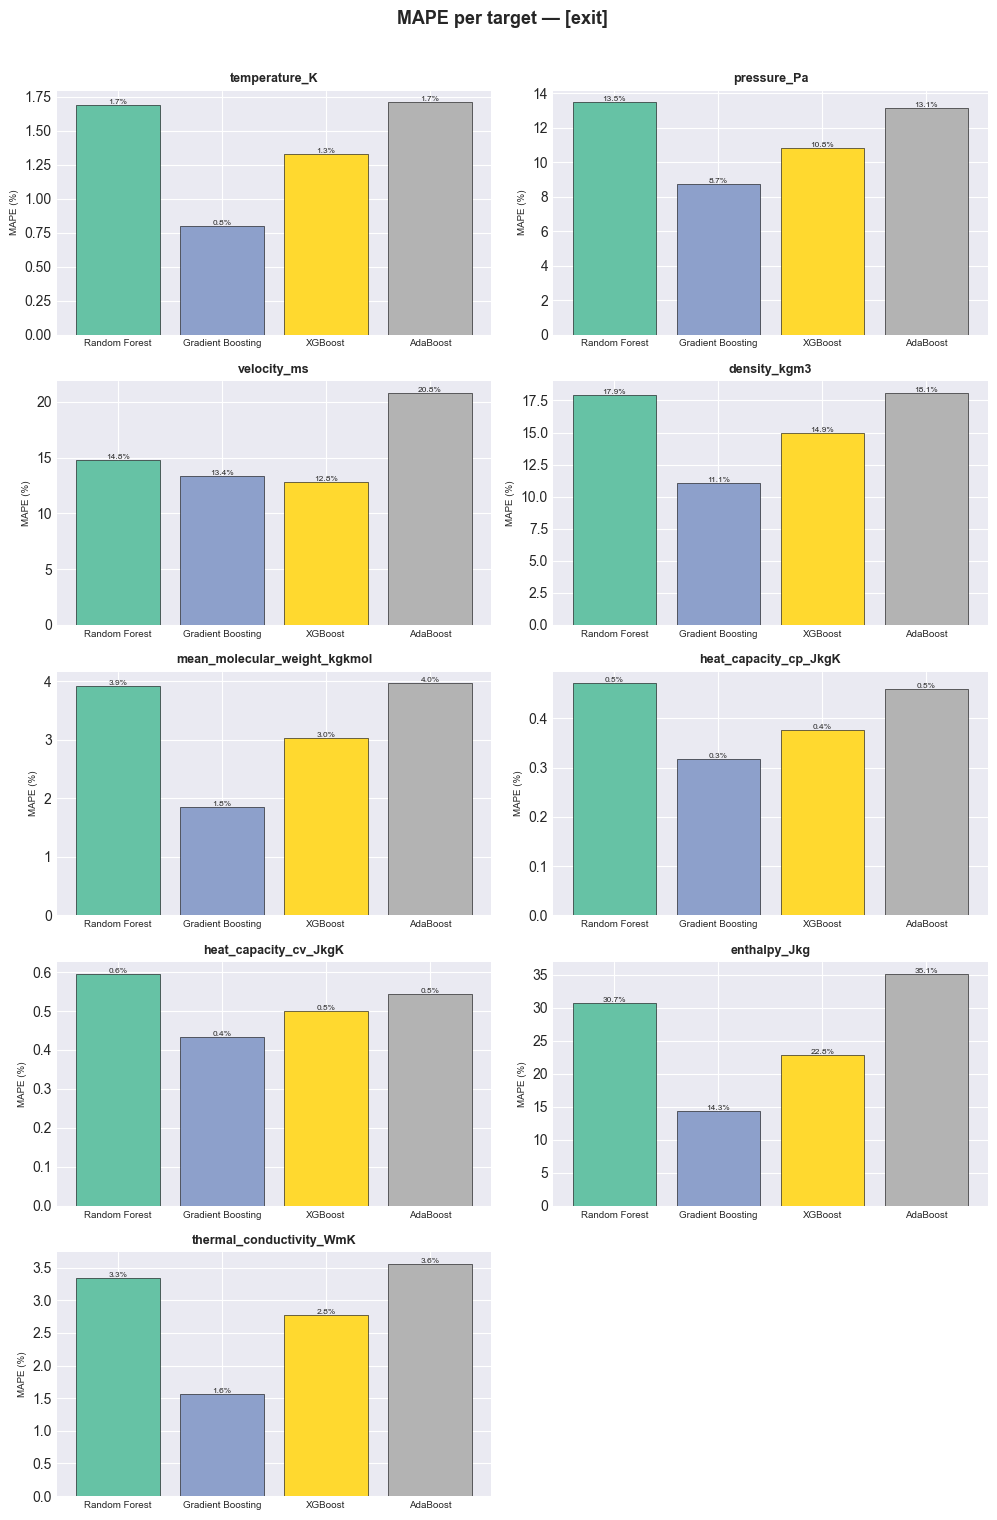

MAPE chart complete.


In [6]:
# ── Section 5: MAPE per target (one subplot per target) ──────────────────────
for mode in df_metrics['mode'].unique():
    sub = df_metrics[df_metrics['mode'] == mode]
    model_names = sub['model'].unique()
    targets = sub['target'].unique()
    colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

    n_targets = len(targets)
    n_cols = 2
    n_rows = int(np.ceil(n_targets / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.0 * n_rows))
    axes = np.atleast_2d(axes)

    for idx, tgt in enumerate(targets):
        ax = axes[idx // n_cols, idx % n_cols]
        tgt_sub = sub[sub['target'] == tgt]
        vals = [tgt_sub.loc[tgt_sub['model'] == m, 'MAPE_%'].values[0] for m in model_names]
        x = np.arange(len(model_names))

        bars = ax.bar(x, vals, color=colors[:len(model_names)], edgecolor='black', linewidth=0.4)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=0, ha='center', fontsize=7)
        ax.set_ylabel('MAPE (%)', fontsize=7)
        ax.set_title(tgt, fontsize=9, fontweight='bold')

        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{v:.1f}%', ha='center', va='bottom', fontsize=6)

    for idx in range(n_targets, n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].set_visible(False)

    fig.suptitle(f'MAPE per target — [{mode}]', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()

    if IF_PLOT_EXPORT:
        fig_dir = Path('outputs/figures') / mode
        fig_dir.mkdir(parents=True, exist_ok=True)
        path = fig_dir / f'model_comparison_MAPE_{mode}.png'
        fig.savefig(path, dpi=150, bbox_inches='tight')
        print(f'  Saved: {path}')

    if IF_PLOT_SHOWN:
        plt.show()
    plt.close(fig)

print('MAPE chart complete.')